In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import PolynomialFeatures


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import BayesianRidge

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

In [2]:
np.random.seed(42)

# Класс 0: компактное облако
X0 = np.random.normal(loc=[0, 0], scale=1, size=(500, 2))
y0 = np.zeros(500)

# Класс 1: компактное облако в стороне
X1 = np.random.normal(loc=[3, 0], scale=1, size=(500, 2))
y1 = np.ones(500)

for noise_dim in range(1, 100, 10):

    print('')
    print('--------------------------------')
    print('noise_dim =', noise_dim)
    print('--------------------------------')
    
# А ТЕПЕРЬ КЛЮЧЕВОЕ — добавляем ШУМОВЫЕ признаки
    noise_features = np.random.normal(0, 2.5, size=(1000, noise_dim))  # 1 useless features!

    X0 = np.hstack([X0, noise_features[:500]])
    X1 = np.hstack([X1, noise_features[500:]])

    X = np.vstack([X0, X1])
    y = np.concatenate([y0, y1])


    horisontal_ax = []

    Accuracy_train_list = []
    Accuracy_test_list = []

    for k in range(5, round(50*len(X)/100), 25):


#         print('k =', k)
        horisontal_ax.append(k)

        accuracy_train_list = []
        accuracy_test_list = []

        for seed in range(10):

            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

            model = KNeighborsClassifier(k)
            model.fit(X_train, y_train)

            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)

            accuracy_train = accuracy_score(y_train, y_train_pred)
            accuracy_test = accuracy_score(y_test, y_test_pred)

            accuracy_train_list.append(accuracy_train)
            accuracy_test_list.append(accuracy_test)

        Accuracy_train_list.append(np.array(accuracy_train_list).mean())
        Accuracy_test_list.append(np.array(accuracy_test_list).mean())
        
    max_score_index = np.argmax(np.array(Accuracy_test_list))

#     plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
#     plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
#     plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
#     plt.plot(horisontal_ax[max_score_index], Accuracy_test_list[max_score_index], 'o')
#     plt.legend()
#     plt.show()
    
    print('Дефолтный скор:', round(np.array(Accuracy_test_list)[0], 4))
    print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4), 'при k =', max_score_index*25 + 5)
    print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))


--------------------------------
noise_dim = 1
--------------------------------
Дефолтный скор: 0.9297
Максимальный скор: 0.9417 при k = 55
Прирост скора: 0.012

--------------------------------
noise_dim = 11
--------------------------------
Дефолтный скор: 0.7867
Максимальный скор: 0.8933 при k = 80
Прирост скора: 0.1067

--------------------------------
noise_dim = 21
--------------------------------
Дефолтный скор: 0.649
Максимальный скор: 0.8343 при k = 205
Прирост скора: 0.1853

--------------------------------
noise_dim = 31
--------------------------------
Дефолтный скор: 0.6137
Максимальный скор: 0.7467 при k = 130
Прирост скора: 0.133

--------------------------------
noise_dim = 41
--------------------------------
Дефолтный скор: 0.596
Максимальный скор: 0.73 при k = 255
Прирост скора: 0.134

--------------------------------
noise_dim = 51
--------------------------------


KeyboardInterrupt: 

--------------------------------
noise_dim = 1
--------------------------------
k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480


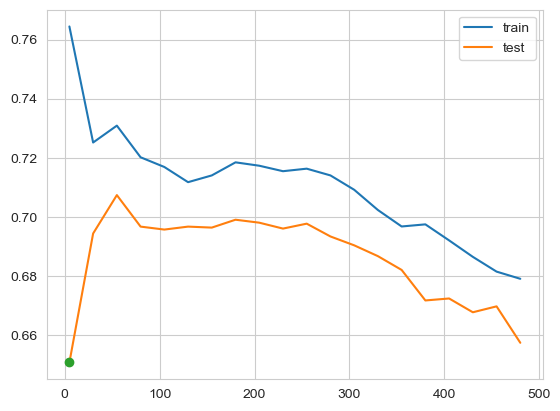

--------------------------------
noise_dim = 11
--------------------------------
k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480


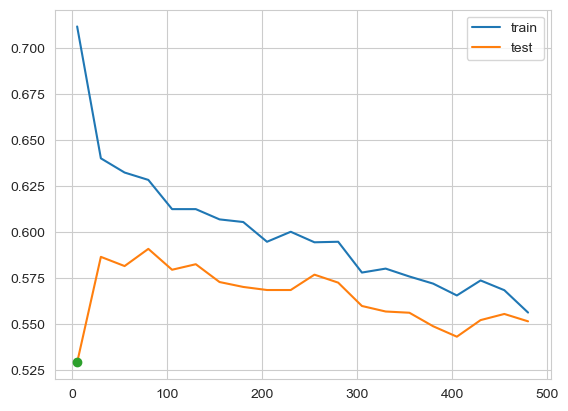

--------------------------------
noise_dim = 21
--------------------------------
k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480


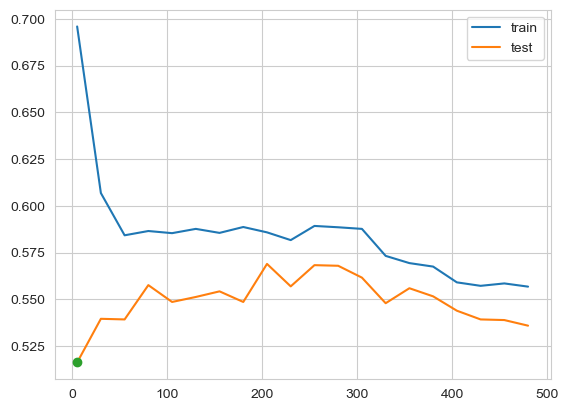

--------------------------------
noise_dim = 31
--------------------------------
k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480


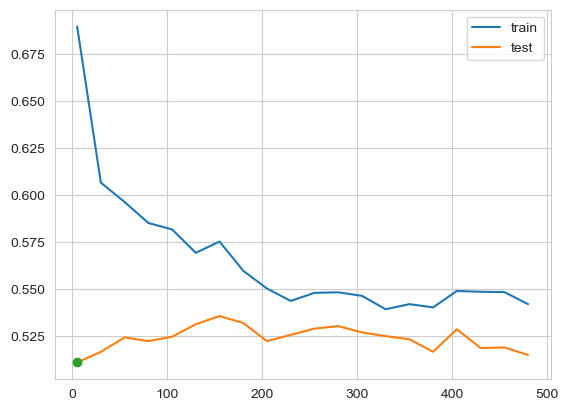

--------------------------------
noise_dim = 41
--------------------------------
k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480


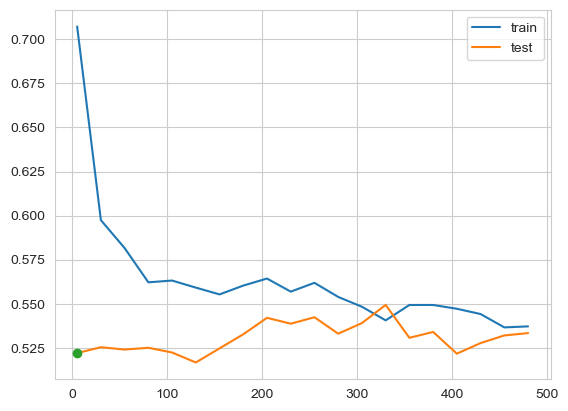

--------------------------------
noise_dim = 51
--------------------------------
k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480


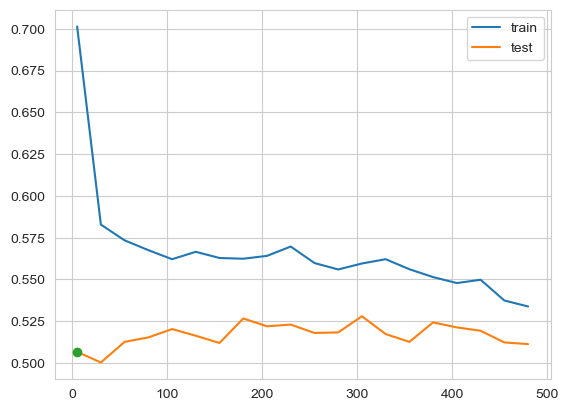

--------------------------------
noise_dim = 61
--------------------------------
k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480


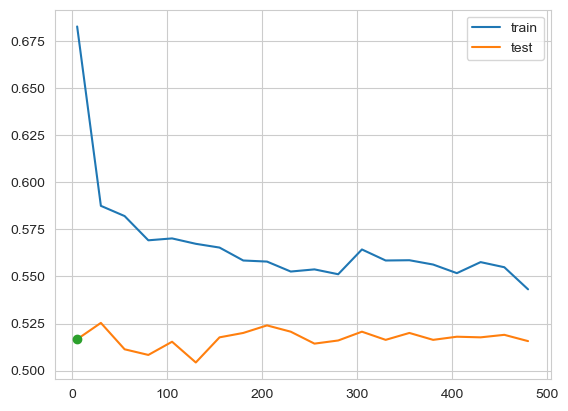

--------------------------------
noise_dim = 71
--------------------------------
k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480


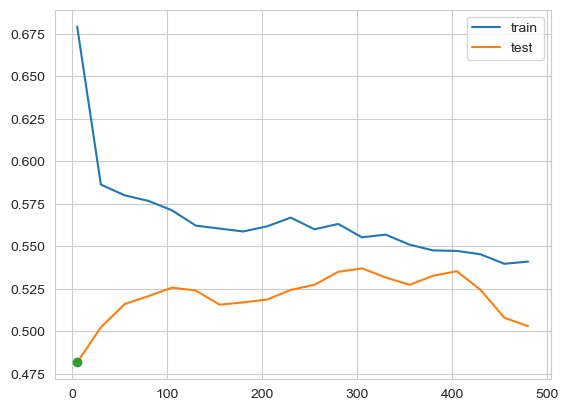

--------------------------------
noise_dim = 81
--------------------------------
k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480


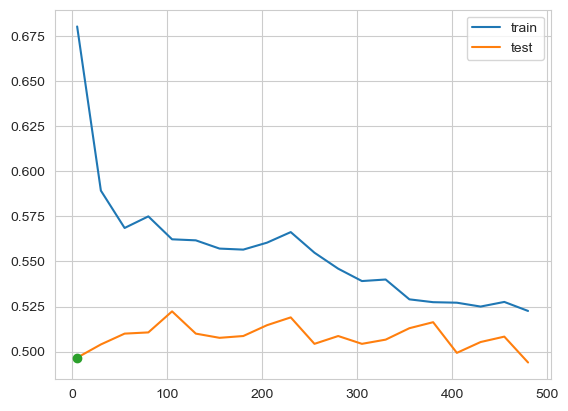

--------------------------------
noise_dim = 91
--------------------------------
k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480


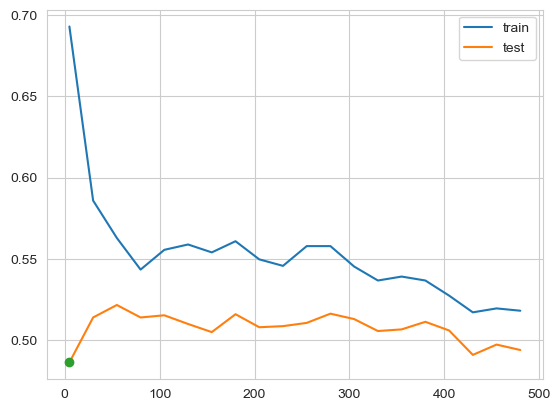

In [2]:
np.random.seed(42)

# Класс 0: компактное облако
X0 = np.random.normal(loc=[0, 0], scale=1, size=(500, 2))
y0 = np.zeros(500)

# Класс 1: компактное облако в стороне
X1 = np.random.normal(loc=[3, 0], scale=1, size=(500, 2))
y1 = np.ones(500)

for noise_dim in range(1, 100, 10):

    
    print('--------------------------------')
    print('noise_dim =', noise_dim)
    print('--------------------------------')
    
# А ТЕПЕРЬ КЛЮЧЕВОЕ — добавляем ШУМОВЫЕ признаки
    noise_features = np.random.normal(0, 2.5, size=(1000, noise_dim))  

    X0 = np.hstack([X0, noise_features[:500]])
    X1 = np.hstack([X1, noise_features[500:]])

    X = np.vstack([X0, X1])
    y = np.concatenate([y0, y1])
    
#     scaler = StandardScaler()
#     X = scaler.fit_transform(X)

    horisontal_ax = []

    Accuracy_train_list = []
    Accuracy_test_list = []

    for k in range(5, round(50*len(X)/100), 25):


        print('k =', k)
        horisontal_ax.append(k)

        accuracy_train_list = []
        accuracy_test_list = []

        for seed in range(10):

            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

            model = KNeighborsClassifier(k)
            model.fit(X_train, y_train)

            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)

            accuracy_train = accuracy_score(y_train, y_train_pred)
            accuracy_test = accuracy_score(y_test, y_test_pred)

            accuracy_train_list.append(accuracy_train)
            accuracy_test_list.append(accuracy_test)

        Accuracy_train_list.append(np.array(accuracy_train_list).mean())
        Accuracy_test_list.append(np.array(accuracy_test_list).mean())

    plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
    plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
    plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
    plt.legend()
    plt.show()

RuntimeError: set_aspect(..., adjustable='datalim') or axis('equal') are not allowed when both axes are shared.  Try set_aspect(..., adjustable='box').

<Figure size 1600x1600 with 16 Axes>